In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from glob import glob
import cv2
import albumentations as A
import numpy as np
from tqdm import tqdm

from torch.utils.data import DataLoader
from dataset import BrainTumorDataset

import torch
import torch.nn as nn
from unet import UNet


plt.style.use("ggplot")
%matplotlib inline

In [2]:
# Setting Size Parameters of images
img_width = 256
img_height = 256

In [3]:
# Image loading
image_filenames = []

mask_files = glob('./Dataset/kaggle_3m/*/*_mask*')

for i in mask_files:
    image_filenames.append(i.replace("_mask", ""))

print(image_filenames[:10])
len(image_filenames)

['./Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_11.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_12.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_13.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_14.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_15.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_16.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_17.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_18.tif', './Dataset/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_19.tif']


3929

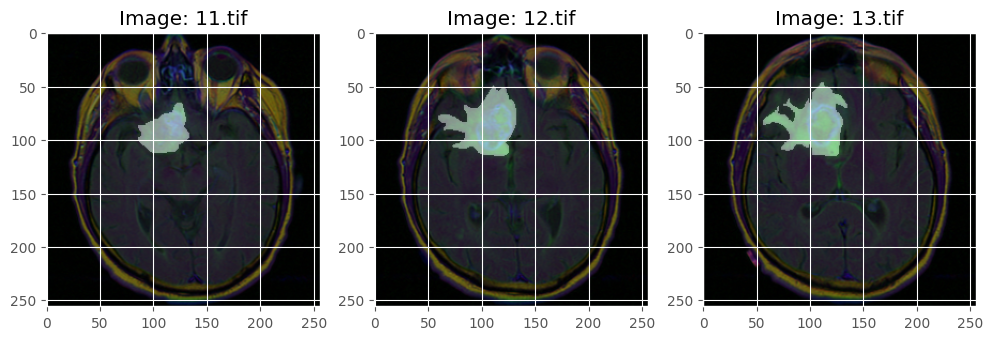

In [4]:
# sample plot of images and masks
def plot_from_img_path(rows, columns, list_img_path, list_mask_path):
    fig = plt.figure(figsize=(12, 12))
    for i in range(1, rows * columns + 1):
        fig.add_subplot(rows, columns, i)
        img_path = list_img_path[i]
        mask_path = list_mask_path[i]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        plt.title(f"Image: {img_path.split('/')[-1][-6:]}")
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)
    plt.show()
    
plot_from_img_path(1,3, image_filenames, mask_files)

In [5]:
# Dataframe creation
df = pd.DataFrame(data={'image_filenames': image_filenames, "mask" : mask_files})
df.shape

(3929, 2)

In [6]:
# Splitting the Dataset

df_train, df_test = train_test_split(df, test_size=0.05) # Test Size - 0.1 means 10%
df_train, df_val = train_test_split(df_train, test_size=0.2)

print(df_train.shape)
print(df_test.shape)
print(df_val.shape)

(2985, 2)
(197, 2)
(747, 2)


In [7]:
# Image Augmentation Parameters
train_transform = A.Compose([
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Resize(256, 256),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1))
])

test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1))
])

/usr/local/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
BATCH_SIZE = 32

train_image_paths = df_train["image_filenames"].values
train_mask_paths = df_train["mask"].values
val_image_paths = df_val["image_filenames"].values
val_mask_paths = df_val["mask"].values
test_image_paths = df_test["image_filenames"].values
test_mask_paths = df_test["mask"].values

train_dataset = BrainTumorDataset(train_image_paths, train_mask_paths, transform=train_transform)
val_dataset = BrainTumorDataset(val_image_paths, val_mask_paths, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


# Example: one batch
images, masks = next(train_loader.__iter__())
print(images.shape, masks.shape)


torch.Size([32, 3, 256, 256]) torch.Size([32, 1, 256, 256])


In [9]:
# Evaluation Metrics
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_flat = y_true.view(-1)
    y_pred_flat = y_pred.view(-1)
    
    intersection = (y_true_flat * y_pred_flat).sum()
    union = y_true_flat.sum() + y_pred_flat.sum()
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
    y_true_flat = y_true.view(-1)
    y_pred_flat = y_pred.view(-1)
    
    intersection = (y_true_flat * y_pred_flat).sum()
    total = (y_true_flat + y_pred_flat).sum()
    
    union = total - intersection
    return (intersection + smooth) / (union + smooth)

# def jaccard_distance(y_true, y_pred, smooth=1e-6):
#     return 1 - iou(y_true, y_pred, smooth)



In [10]:
# Trainning function

EPOCHS = 5
learning_rate = 1e-4
device="cuda"

def train_unet(model, train_loader, val_loader, num_epochs=EPOCHS, lr=learning_rate, device="cuda"):
    criterion_bce = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

    best_val_loss = float("inf")

    history = {
        "train_loss": [], "val_loss": [],
        "train_dice": [], "val_dice": [],
        "train_iou": [], "val_iou": []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- TRAINING ----
        model.train()
        train_loss, train_dice, train_iou = 0, 0, 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)
        for imgs, masks in train_bar:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)

            bce = criterion_bce(outputs, masks)
            dice = dice_loss(masks, outputs)
            loss = 0.5 * bce + 0.5 * dice

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_coefficient(masks, outputs).item()
            train_iou += iou(masks, outputs).item()

            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)

        # ---- VALIDATION ----
        model.eval()
        val_loss, val_dice, val_iou = 0, 0, 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)
        with torch.no_grad():
            for imgs, masks in val_bar:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model(imgs)

                bce = criterion_bce(outputs, masks)
                dice = dice_loss(masks, outputs)
                loss = 0.5 * bce + 0.5 * dice

                val_loss += loss.item()
                val_dice += dice_coefficient(masks, outputs).item()
                val_iou += iou(masks, outputs).item()

                val_bar.set_postfix(loss=loss.item())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_dice"].append(avg_train_dice)
        history["val_dice"].append(avg_val_dice)
        history["train_iou"].append(avg_train_iou)
        history["val_iou"].append(avg_val_iou)

        scheduler.step(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} "
              f"| Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_unet.pth")
            print("Saved best model")

    return model, history



In [ ]:
# Train model
model = UNet().to(device)
model, history = train_unet(model, train_loader, val_loader, num_epochs=50, lr=1e-4, device=device)

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot Dice Score
plt.figure(figsize=(10,5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Validation Dice")
plt.xlabel("Epochs")
plt.ylabel("Dice Coefficient")
plt.title("Training vs Validation Dice Score")
plt.legend()
plt.show()

# Plot IoU
plt.figure(figsize=(10,5))
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("IoU")
plt.title("Training vs Validation IoU")
plt.legend()
plt.show()



Epoch 1/50


Training:   0%|          | 0/94 [00:00<?, ?it/s]